# 02 — Clasificación LLM y perfilado de usuarios — Exploit.in

Clasifica ~5.000 posts de las secciones de interés para threat intelligence  
y construye perfiles de los usuarios más activos.

**Modelo**: `qwen2.5:14b`  
**Categorías de clasificación**:

| Categoría | Descripción |
|---|---|
| `hacking` | Intrusión, vulnerabilidades, exploits, pentesting |
| `carding` | Fraude con tarjetas, dumps, CVV, sistemas de pago |
| `malware` | Troyanos, bots, crypters, exploits, ransomware |
| `spam` | Redes de spam, mailing masivo, scrapers, bases de datos |
| `marketplace` | Compraventa de servicios/credenciales/accesos |
| `programming` | Código, scripts, desarrollo, automatización |
| `community` | Discusión técnica general, preguntas, debate |
| `unknown` | No clasificable |

Produce:
- `data/processed/exploitin_sample_classified.parquet`
- `data/processed/exploitin_user_profiles.json`

## 0. Setup

In [1]:
# "json" es la librería estándar de Python para leer y escribir archivos JSON.
# JSON (JavaScript Object Notation) es un formato de texto muy usado para guardar datos
# estructurados como diccionarios y listas, similar a un diccionario de Python.
import json

# "re" para trabajar con expresiones regulares (búsqueda de patrones en texto).
# Lo usamos para extraer el bloque JSON de la respuesta del LLM.
import re

# "pandas" para trabajar con tablas de datos.
import pandas as pd

# "numpy" para operaciones matemáticas (aunque aquí solo lo usamos para funciones básicas).
import numpy as np

# "matplotlib.pyplot" para crear gráficas.
import matplotlib.pyplot as plt

# "ollama" es la librería que nos permite hablar con modelos de lenguaje (LLMs)
# que están ejecutándose localmente en nuestra máquina.
# En lugar de enviar datos a la nube (OpenAI, etc.), ollama los procesa localmente.
import ollama

# "pathlib.Path" para manejar rutas de archivos.
from pathlib import Path

# "tqdm" es una librería para mostrar barras de progreso en Python.
# "tqdm.auto" elige automáticamente entre la versión para notebooks y la versión de terminal.
from tqdm.auto import tqdm

# "IPython.display.display" para mostrar tablas formateadas en el notebook.
from IPython.display import display

# Ruta de la carpeta con los archivos procesados.
PROCESSED   = Path('data/processed')

# Nombre del modelo de lenguaje local que usaremos para clasificar los posts.
# qwen2.5:14b es un modelo de 14 mil millones de parámetros, capaz de entender ruso e inglés.
MODEL       = 'qwen2.5:14b'

# Rutas de los archivos de salida que generará este notebook.
SAMPLE_OUT   = PROCESSED / 'exploitin_sample_classified.parquet'  # posts clasificados
PROFILES_OUT = PROCESSED / 'exploitin_user_profiles.json'         # perfiles de usuarios
CHECKPOINT   = PROCESSED / 'exploitin_classify_checkpoint.parquet' # guardado intermedio

# Lista de categorías válidas para clasificar los posts.
# Si el LLM devuelve algo que no está en esta lista, lo asignamos a 'unknown'.
CATEGORIES = ['hacking', 'carding', 'malware', 'spam', 'marketplace', 'programming', 'community', 'unknown']

# Cargamos las tablas base desde los Parquets generados en el notebook 00.
posts   = pd.read_parquet(PROCESSED / 'posts.parquet')
topics  = pd.read_parquet(PROCESSED / 'topics.parquet')
forums  = pd.read_parquet(PROCESSED / 'forums.parquet')
members = pd.read_parquet(PROCESSED / 'members.parquet')

# Creamos diccionarios de traducción y añadimos el nombre de sección a cada post.
forum_name_map  = dict(zip(forums['id'], forums['name']))
topic_forum_map = dict(zip(topics['tid'], topics['forum_id']))
posts = posts.copy()
posts['forum_id']   = posts['topic_id'].map(topic_forum_map)
posts['forum_name'] = posts['forum_id'].map(forum_name_map)

print(f'Setup OK  |  Modelo: {MODEL}')

Setup OK  |  Modelo: qwen2.5:14b


/home/drjekyll/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Selección de muestra

~5.000 posts de secciones relevantes para threat intelligence,  
con sampling proporcional al peso de cada sección.

In [2]:
# Diccionario que define cuántos posts tomar de cada sección del foro.
# "None" significa "tomar todos los posts disponibles" (para secciones pequeñas).
# Las cuotas son proporcionales al tamaño e importancia de cada sección para el análisis.
SECTION_QUOTAS = {
    'Безопасность и взлом':         800,   # Seguridad y hacking
    'Деньги':                        600,   # Dinero
    'Покупка/Продажа/Обмен/Работа':  900,   # Marketplace (el más grande)
    'Вирусология':                   None,  # Virología — tomamos todos (~597 posts)
    'Программирование':              400,   # Programación
    '1st Access Level':              800,   # Sección premium nivel 1
    'Black List':                    None,  # Lista negra — tomamos todos (~492 posts)
    'Криптография и приватность':    300,   # Criptografía y privacidad
    'Спам, рассылки':                400,   # Spam y correo masivo
}

# Filtramos los posts con contenido de más de 60 caracteres para descartar
# respuestas muy cortas que no aportan información suficiente para clasificar.
posts_clean = posts[
    posts['content'].str.len() > 60
].copy()

# Renombramos la columna 'author_name' a 'username' para ser coherentes con el
# nombre que usamos en otros módulos del proyecto (ContiLeaks, BlackBasta, LockBit).
posts_clean = posts_clean.rename(columns={'author_name': 'username'})

# Construimos la muestra combinando posts de todas las secciones seleccionadas.
parts = []
for section, quota in SECTION_QUOTAS.items():
    # Obtenemos todos los posts de esta sección.
    sec_posts = posts_clean[posts_clean['forum_name'] == section]

    # Si no hay cuota (None) o hay menos posts que la cuota, tomamos todos.
    # Si hay más posts que la cuota, tomamos una muestra aleatoria reproducible (random_state=42).
    if quota is None or len(sec_posts) <= quota:
        parts.append(sec_posts)
    else:
        parts.append(sec_posts.sample(quota, random_state=42))

# "pd.concat()" une una lista de DataFrames en uno solo.
# "ignore_index=True" reinicia el índice del DataFrame resultante desde 0.
sample = pd.concat(parts, ignore_index=True)

# Añadimos una columna vacía 'category' que se irá rellenando durante la clasificación.
sample['category'] = None

print('Muestra por sección:')
for sec, grp in sample.groupby('forum_name', sort=False):
    print(f'  {sec:40s} {len(grp):5,} posts  ({grp["username"].nunique()} autores únicos)')
print(f'\nTotal muestra : {len(sample):,} posts')
print(f'Autores únicos: {sample["username"].nunique():,}')

Muestra por sección:
  Безопасность и взлом                       800 posts  (331 autores únicos)
  Деньги                                     600 posts  (244 autores únicos)
  Покупка/Продажа/Обмен/Работа               900 posts  (478 autores únicos)
  Вирусология                                597 posts  (195 autores únicos)
  Программирование                           400 posts  (171 autores únicos)
  1st Access Level                           800 posts  (165 autores únicos)
  Black List                                 492 posts  (150 autores únicos)
  Криптография и приватность                 300 posts  (131 autores únicos)
  Спам, рассылки                             400 posts  (150 autores únicos)

Total muestra : 5,289 posts
Autores únicos: 1,081


## 2. Clasificación LLM

Cada post se clasifica con una sola llamada a `qwen2.5:14b`.  
Checkpoint cada 100 posts para poder reanudar si se interrumpe.

In [3]:
# "System prompt" del clasificador: instrucciones en inglés que le decimos al LLM
# al principio de la conversación para configurar su comportamiento.
# El LLM actúa como un analista de inteligencia de amenazas y clasifica el texto
# en exactamente una de las 8 categorías definidas.
SYSTEM_CLASSIFY = """You are a threat intelligence analyst classifying posts from a Russian underground hacking forum (Exploit.in, 2005-2008).

Classify each post into EXACTLY ONE category:
- hacking     : network intrusion, vulnerability exploitation, web hacking, password cracking, pentesting techniques
- carding     : credit card fraud, dumps, CVV, PayPal/e-money fraud, banking fraud
- malware     : trojans, bots, crypters, keyloggers, ransomware, virus development or sharing
- spam        : bulk email, spam services, scrapers, mailing databases, SMS spam
- marketplace : buying/selling/exchanging credentials, shells, ICQ numbers, services, accounts (general trade)
- programming : code snippets, scripts, programming questions, development tools, automation
- community   : general technical discussion, forum questions, off-topic, greetings, opinion, debates
- unknown     : cannot determine from the text

Reply with ONLY the category name, nothing else."""


def classify_post(content: str) -> str:
    """
    Envía un post al modelo LLM local y recibe una categoría como respuesta.

    El LLM recibe el system prompt (instrucciones) y el texto del post,
    y devuelve solo el nombre de una categoría en minúsculas.

    Parámetros:
        content (str): El texto del post a clasificar.

    Devuelve:
        str: La categoría asignada (una de las 8 categorías válidas), o 'unknown'
             si el LLM no devolvió algo reconocible o si ocurrió un error.
    """
    try:
        # Enviamos el post al modelo local via ollama.
        # "messages" es una lista de turnos de conversación, igual que en ChatGPT:
        # - 'system': instrucciones generales del comportamiento del modelo
        # - 'user': el texto que queremos clasificar
        resp = ollama.chat(
            model=MODEL,
            messages=[
                {'role': 'system', 'content': SYSTEM_CLASSIFY},
                # Solo enviamos los primeros 600 caracteres del post para ahorrar tiempo
                # de inferencia. Los primeros 600 chars suelen ser suficientes para clasificar.
                {'role': 'user',   'content': content[:600]},
            ],
            # "temperature": 0.0 = el modelo siempre elige la respuesta más probable (sin aleatoriedad).
            # Esto da resultados más reproducibles para clasificación.
            # "num_predict": 10 = máximo 10 tokens de respuesta (solo necesitamos una palabra).
            options={'temperature': 0.0, 'num_predict': 10},
        )

        # Limpiamos la respuesta: minúsculas y sin espacios sobrantes.
        raw = resp.message.content.strip().lower()

        # Dividimos la respuesta en palabras y buscamos la primera que sea una categoría válida.
        # El LLM a veces añade puntos o comas, por eso usamos split con múltiples separadores.
        for word in re.split(r'[\s,;.\n]+', raw):
            if word in CATEGORIES:
                return word

        # Si ninguna palabra de la respuesta es una categoría válida, devolvemos 'unknown'.
        return 'unknown'

    except Exception:
        # Si hay cualquier error de conexión con ollama, devolvemos 'unknown' en lugar de crashear.
        return 'unknown'

In [4]:
# Sistema de checkpoint: permite retomar la clasificación si se interrumpe.
# Clasificar 5.289 posts con un LLM local tarda ~14 minutos. Si el notebook
# se cierra o hay un error, el checkpoint nos permite continuar desde donde lo dejamos
# en lugar de empezar desde cero.
if CHECKPOINT.exists():
    # Si ya existe un checkpoint, cargamos los posts ya clasificados.
    done = pd.read_parquet(CHECKPOINT)
    # Creamos un conjunto (set) con los IDs de los posts ya procesados.
    # Un "set" permite buscar si un elemento está contenido en él muy rápidamente.
    done_ids = set(done['pid'])
    print(f'Checkpoint: {len(done_ids):,} posts ya clasificados')
else:
    # Si no hay checkpoint, empezamos desde cero.
    done = pd.DataFrame(columns=sample.columns)
    done_ids = set()
    print('Sin checkpoint — clasificando desde cero')

# Filtramos para quedarnos solo con los posts que AÚN NO han sido clasificados.
# "~" invierte la máscara: ".isin(done_ids)" da True si está clasificado;
# con "~" obtenemos los que NO están clasificados.
pending = sample[~sample['pid'].isin(done_ids)].copy()
print(f'Pendientes: {len(pending):,}')

# Número de posts entre guardados intermedios (checkpoints).
BATCH_CHECKPOINT = 100

# Inicializamos la lista de resultados con los ya clasificados (si los hay).
results    = list(done.itertuples(index=False, name=None)) if len(done) else []
done_rows  = done.to_dict('records') if len(done) else []

# Bucle principal de clasificación: iteramos sobre cada post pendiente.
# "tqdm" envuelve el iterador para mostrar una barra de progreso con tiempo estimado.
for i, row in enumerate(tqdm(pending.itertuples(index=False), total=len(pending), desc='Clasificando')):
    # Llamamos al LLM para que clasifique este post.
    cat = classify_post(row.content)

    # Creamos un diccionario con todos los campos del post más la categoría asignada.
    # "getattr(row, col)" obtiene el valor del campo 'col' de la fila 'row'.
    record = {col: getattr(row, col) for col in pending.columns}
    record['category'] = cat
    done_rows.append(record)

    # Cada 100 posts, guardamos un checkpoint en disco para no perder el progreso.
    if (i + 1) % BATCH_CHECKPOINT == 0:
        pd.DataFrame(done_rows).to_parquet(CHECKPOINT, index=False)

# Guardamos el resultado final completo en el archivo de salida definitivo.
classified = pd.DataFrame(done_rows)
classified.to_parquet(SAMPLE_OUT, index=False)

# Eliminamos el archivo de checkpoint temporal (ya no lo necesitamos).
# "missing_ok=True" evita un error si el archivo no existe.
CHECKPOINT.unlink(missing_ok=True)

print(f'\nClasificación completada: {len(classified):,} posts')
print(classified['category'].value_counts().to_string())

Sin checkpoint — clasificando desde cero
Pendientes: 5,289


Clasificando:   0%|          | 0/5289 [00:00<?, ?it/s]

Clasificando:   0%|          | 1/5289 [00:02<2:58:26,  2.02s/it]

Clasificando:   0%|          | 2/5289 [00:02<1:23:47,  1.05it/s]

Clasificando:   0%|          | 3/5289 [00:02<54:02,  1.63it/s]  

...

Clasificando: 100%|█████████▉| 5287/5289 [14:14<00:00,  5.63it/s]

Clasificando: 100%|█████████▉| 5288/5289 [14:14<00:00,  6.02it/s]

Clasificando: 100%|██████████| 5289/5289 [14:14<00:00,  6.41it/s]

Clasificando: 100%|██████████| 5289/5289 [14:14<00:00,  6.19it/s]


Clasificación completada: 5,289 posts
category
community      1568
hacking         784
marketplace     775
programming     694
malware         658
spam            404
carding         291
unknown         115


## 3. Distribución de categorías

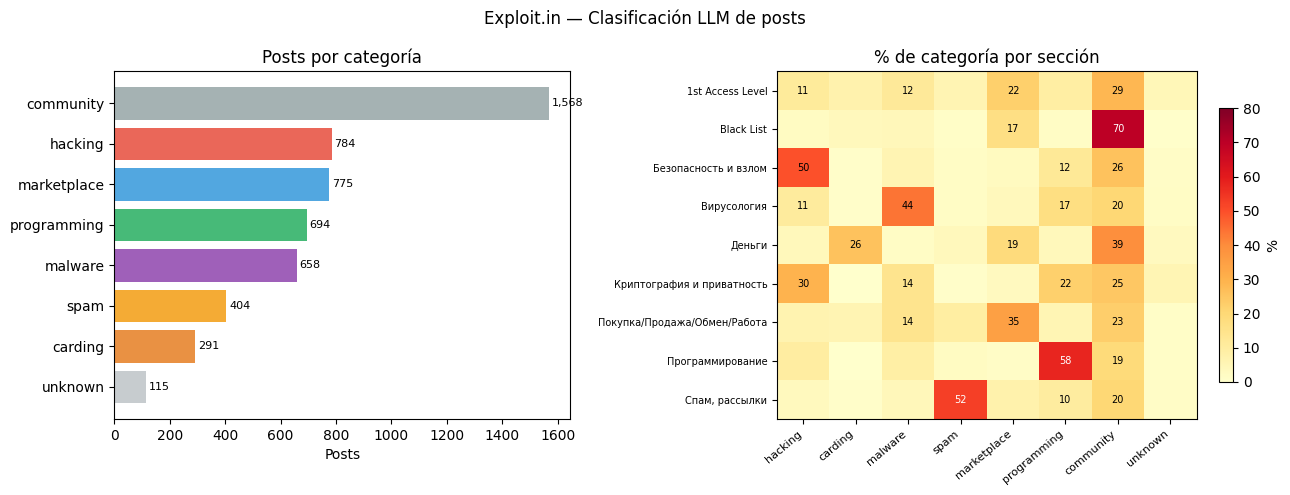


Resumen: 5,289 posts clasificados
  Sin clasificar (unknown): 115 (2.2%)


In [5]:
# Cargamos los posts ya clasificados desde el Parquet guardado por la celda anterior.
# (Al re-ejecutar el notebook, esto permite saltarse la clasificación si ya está hecha.)
classified = pd.read_parquet(SAMPLE_OUT)

# Contamos cuántos posts hay en cada categoría y ordenamos de más a menos.
cat_counts = classified['category'].value_counts()

# Paleta de colores para identificar visualmente cada categoría en las gráficas.
# Cada categoría tiene un color asociado que se usará de forma consistente.
cat_colors = {
    'hacking':     '#e74c3c',   # rojo
    'carding':     '#e67e22',   # naranja
    'malware':     '#8e44ad',   # púrpura
    'spam':        '#f39c12',   # amarillo-naranja
    'marketplace': '#3498db',   # azul
    'programming': '#27ae60',   # verde
    'community':   '#95a5a6',   # gris medio
    'unknown':     '#bdc3c7',   # gris claro
}

# Creamos una figura con dos gráficas lado a lado.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfica izquierda: barras horizontales con el número de posts por categoría.
# Creamos la lista de colores en el mismo orden en que aparecen las categorías.
colors = [cat_colors.get(c, '#aaa') for c in cat_counts.index]
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color=colors[::-1], alpha=0.85)
axes[0].set_title('Posts por categoría')
axes[0].set_xlabel('Posts')
# Añadimos etiquetas numéricas al final de cada barra.
for bar, val in zip(axes[0].patches, cat_counts.values[::-1]):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)

# Gráfica derecha: heatmap de sección del foro × categoría LLM.
# "pd.crosstab()" crea una tabla de contingencia contando cuántos posts
# hay para cada combinación de sección de foro y categoría.
cross = pd.crosstab(classified['forum_name'], classified['category'])
# Reordenamos las columnas para que sigan el orden de CATEGORIES.
cross = cross[[c for c in CATEGORIES if c in cross.columns]]
# Normalizamos por fila: en lugar de contar posts, calculamos qué % de cada sección
# corresponde a cada categoría. Esto permite comparar secciones de distinto tamaño.
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

# "imshow" muestra la matriz de porcentajes como una imagen coloreada (mapa de calor).
# "vmin=0, vmax=80" fija la escala de colores entre 0% y 80%.
im = axes[1].imshow(cross_pct.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=80)
axes[1].set_xticks(range(len(cross_pct.columns)))
axes[1].set_xticklabels(cross_pct.columns, rotation=40, ha='right', fontsize=8)
axes[1].set_yticks(range(len(cross_pct.index)))
# Truncamos los nombres largos de secciones para que quepan en el eje.
axes[1].set_yticklabels([s[:30] for s in cross_pct.index], fontsize=7)
axes[1].set_title('% de categoría por sección')
plt.colorbar(im, ax=axes[1], fraction=0.03, label='%')

# Añadimos las etiquetas numéricas dentro del heatmap para las celdas con valor > 10%.
# El color del texto cambia según el fondo (blanco para valores altos, negro para bajos).
for i in range(len(cross_pct.index)):
    for j in range(len(cross_pct.columns)):
        v = cross_pct.values[i, j]
        if v > 10:
            axes[1].text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7,
                         color='white' if v > 50 else 'black')

plt.suptitle('Exploit.in — Clasificación LLM de posts', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nResumen: {len(classified):,} posts clasificados')
print(f'  Sin clasificar (unknown): {(classified["category"]=="unknown").sum():,} ({(classified["category"]=="unknown").mean()*100:.1f}%)')

## 4. Perfilado de usuarios

Para cada usuario con ≥ 8 posts en la muestra, el LLM genera un perfil  
con su especialidad, rol en la comunidad y resumen de actividad.

In [6]:
# "System prompt" para el perfilado de usuarios.
# Instrucciones más complejas: el LLM debe analizar MÚLTIPLES posts de un mismo
# usuario y devolver un perfil estructurado en formato JSON con varios campos.
SYSTEM_PROFILE = """You are a threat intelligence analyst profiling members of Exploit.in, a Russian underground hacking forum (2005-2008).

Given a selection of posts from a single user, return a JSON profile with these fields:
- "specialty": primary area of activity — one of: hacking, carding, malware, spam, marketplace, programming, community
- "role": their role in the ecosystem — one of: seller, buyer, teacher, developer, moderator, community_member, scammer, unknown
- "confidence": how confident you are — one of: high, medium, low
- "summary": 1-2 sentences in English describing their activity and typical behavior
- "evidence": list of 2-3 short quotes or paraphrases from their posts that support the profile

Return ONLY valid JSON, no explanation."""


def profile_user(username: str, user_posts: list[str]) -> dict:
    """
    Genera un perfil de inteligencia de amenazas para un usuario del foro,
    analizando una muestra de sus posts con el LLM.

    El LLM recibe el nombre del usuario y hasta 15 de sus posts,
    y devuelve un diccionario JSON con su especialidad, rol, confianza en la
    clasificación, resumen de actividad y evidencia textual.

    Parámetros:
        username (str): El nombre de usuario en el foro.
        user_posts (list[str]): Lista de textos de posts publicados por ese usuario.

    Devuelve:
        dict: Diccionario con los campos del perfil (specialty, role, confidence,
              summary, evidence), o un perfil por defecto con 'unknown' si hay error.
    """
    # Limitamos a 15 posts por usuario para no sobrepasar el contexto del LLM
    # y para mantener un tiempo de inferencia razonable.
    sample_posts = user_posts[:15]

    # Unimos los posts con un separador "---" para que el LLM pueda distinguirlos.
    # Cada post se trunca a 300 caracteres para ahorrar tokens.
    posts_text = '\n---\n'.join(p[:300] for p in sample_posts)

    # El "prompt" de usuario incluye el nombre del usuario y sus posts.
    prompt = f'Username: {username}\n\nPosts:\n{posts_text}'

    try:
        # Enviamos la solicitud al LLM con las instrucciones del sistema y el prompt.
        resp = ollama.chat(
            model=MODEL,
            messages=[
                {'role': 'system', 'content': SYSTEM_PROFILE},
                {'role': 'user',   'content': prompt},
            ],
            # "temperature": 0.1 — un poco de aleatoriedad para que el resumen sea más natural,
            # pero sin ser demasiado creativo o inventar información.
            # "num_predict": 300 — suficientes tokens para un perfil JSON completo.
            options={'temperature': 0.1, 'num_predict': 300},
        )
        raw = resp.message.content.strip()

        # El LLM puede añadir texto antes o después del JSON.
        # Usamos una expresión regular para extraer solo el bloque JSON ({...}).
        # "re.DOTALL" hace que "." también coincida con saltos de línea.
        m = re.search(r'\{.*\}', raw, re.DOTALL)

        # Si encontramos un bloque JSON, lo parseamos con json.loads().
        # Si no, devolvemos un perfil por defecto con valores 'unknown'.
        return json.loads(m.group()) if m else {'specialty': 'unknown', 'role': 'unknown',
                                                 'confidence': 'low', 'summary': '', 'evidence': []}
    except Exception:
        # Si hay cualquier error (conexión, JSON inválido, etc.), devolvemos un perfil vacío.
        return {'specialty': 'unknown', 'role': 'unknown',
                'confidence': 'low', 'summary': '', 'evidence': []}

In [7]:
# Solo perfilamos usuarios con al menos MIN_POSTS posts en la muestra clasificada,
# para que el LLM tenga suficiente contexto para hacer un análisis significativo.
# Con muy pocos posts, el perfil podría ser muy impreciso.
MIN_POSTS = 8

# Contamos cuántos posts tiene cada usuario en la muestra clasificada.
user_post_counts = classified.groupby('username').size()

# Filtramos los usuarios que superan el umbral mínimo.
active_users = user_post_counts[user_post_counts >= MIN_POSTS].index.tolist()
print(f'Usuarios con ≥{MIN_POSTS} posts en la muestra: {len(active_users)}')

# Cargamos los perfiles ya calculados si existen (para no repetir trabajo).
profiles_path = PROCESSED / 'exploitin_user_profiles.json'
if profiles_path.exists():
    with open(profiles_path) as f:
        profiles = json.load(f)
    print(f'Perfiles ya calculados: {len(profiles)}')
else:
    # Si no existe el archivo, empezamos con un diccionario vacío.
    profiles = {}

# Usuarios que aún no tienen perfil calculado.
pending_users = [u for u in active_users if u not in profiles]
print(f'Pendientes: {len(pending_users)}')

# Bucle principal de perfilado: iteramos sobre cada usuario pendiente.
for user in tqdm(pending_users, desc='Perfilando usuarios'):
    # Obtenemos todos los posts de este usuario en la muestra clasificada.
    user_posts = classified[classified['username'] == user]['content'].tolist()

    # Llamamos al LLM para que genere el perfil del usuario.
    profiles[user] = profile_user(user, user_posts)

    # Guardamos un checkpoint cada 20 usuarios para no perder el progreso.
    # "ensure_ascii=False" permite guardar caracteres cirílicos sin escaparlos.
    # "indent=2" formatea el JSON con sangría para que sea legible por humanos.
    if len(profiles) % 20 == 0:
        with open(profiles_path, 'w', encoding='utf-8') as f:
            json.dump(profiles, f, ensure_ascii=False, indent=2)

# Guardado final con todos los perfiles.
with open(profiles_path, 'w', encoding='utf-8') as f:
    json.dump(profiles, f, ensure_ascii=False, indent=2)

print(f'\nPerfiles guardados: {len(profiles)}')

Usuarios con ≥8 posts en la muestra: 156
Pendientes: 156


Perfilando usuarios:   0%|          | 0/156 [00:00<?, ?it/s]

Perfilando usuarios:   1%|          | 1/156 [00:05<13:15,  5.13s/it]

Perfilando usuarios:   1%|▏         | 2/156 [00:11<14:51,  5.79s/it]

Perfilando usuarios:   2%|▏         | 3/156 [00:18<16:18,  6.39s/it]

...

Perfilando usuarios:  99%|█████████▊| 154/156 [14:39<00:12,  6.30s/it]

Perfilando usuarios:  99%|█████████▉| 155/156 [14:45<00:06,  6.07s/it]

Perfilando usuarios: 100%|██████████| 156/156 [14:49<00:00,  5.44s/it]

Perfilando usuarios: 100%|██████████| 156/156 [14:49<00:00,  5.70s/it]


Perfiles guardados: 156


## 5. Análisis de perfiles

=== DISTRIBUCIÓN DE ESPECIALIDADES ===
specialty
hacking        45
malware        33
programming    22
carding        16
spam           12
community      11
unknown        11
scamming        3
marketplace     3

=== DISTRIBUCIÓN DE ROLES ===
role
community_member    51
seller              33
teacher             23
developer           20
unknown             11
moderator            8
buyer                7
scammer              3


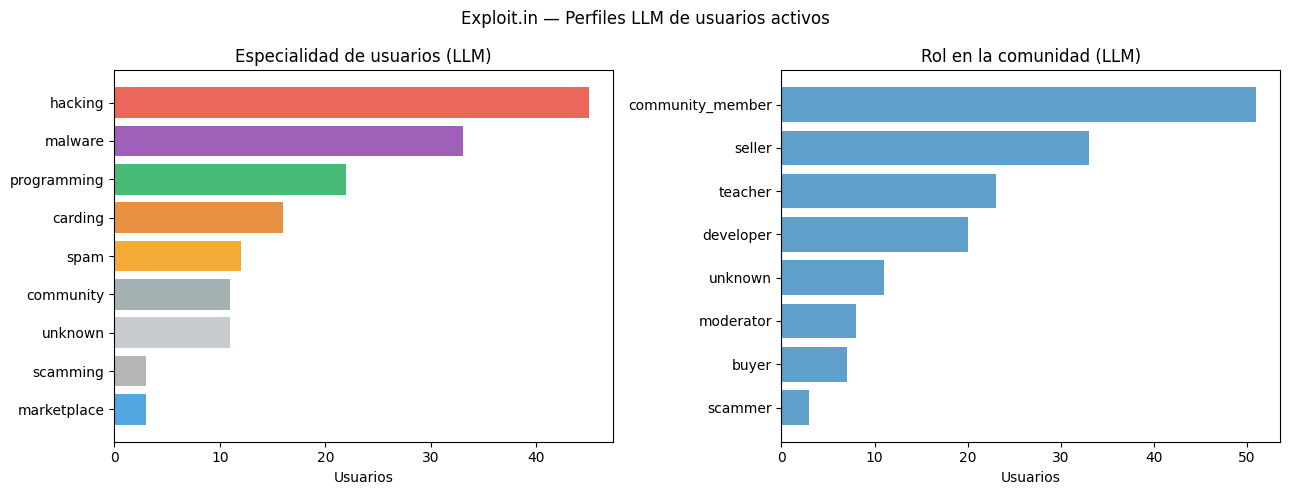

In [8]:
# Cargamos los perfiles JSON guardados en disco.
with open(PROFILES_OUT) as f:
    profiles = json.load(f)

# Convertimos el diccionario de perfiles en un DataFrame de pandas para facilitar el análisis.
# Iteramos sobre cada entrada del diccionario (u = username, p = perfil JSON).
# ".get(campo, valor_por_defecto)" extrae el campo del perfil de forma segura:
# si el campo no existe, usa el valor por defecto.
profiles_df = pd.DataFrame([
    {
        'username':     u,
        'specialty':    p.get('specialty', 'unknown'),
        'role':         p.get('role', 'unknown'),
        'confidence':   p.get('confidence', 'low'),
        'summary':      p.get('summary', ''),
        # "user_post_counts.get(u, 0)" obtiene el número de posts del usuario en la muestra.
        # Si el usuario no está en el conteo, devuelve 0 por defecto.
        'posts_sample': user_post_counts.get(u, 0),
    }
    for u, p in profiles.items()
])

print('=== DISTRIBUCIÓN DE ESPECIALIDADES ===')
print(profiles_df['specialty'].value_counts().to_string())
print('\n=== DISTRIBUCIÓN DE ROLES ===')
print(profiles_df['role'].value_counts().to_string())

# Creamos una figura con dos gráficas: especialidades y roles.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfica izquierda: distribución de especialidades (coloreada con la paleta cat_colors).
spec_counts = profiles_df['specialty'].value_counts()
colors_spec = [cat_colors.get(c, '#aaa') for c in spec_counts.index]
axes[0].barh(spec_counts.index[::-1], spec_counts.values[::-1], color=colors_spec[::-1], alpha=0.85)
axes[0].set_title('Especialidad de usuarios (LLM)')
axes[0].set_xlabel('Usuarios')

# Gráfica derecha: distribución de roles en el ecosistema underground.
role_counts = profiles_df['role'].value_counts()
axes[1].barh(role_counts.index[::-1], role_counts.values[::-1], color='#2980b9', alpha=0.75)
axes[1].set_title('Rol en la comunidad (LLM)')
axes[1].set_xlabel('Usuarios')

plt.suptitle('Exploit.in — Perfiles LLM de usuarios activos', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# Creamos una tabla cruzada de especialidad × rol para ver qué combinaciones son más comunes.
# "pd.crosstab()" cuenta cuántos usuarios tienen cada combinación de (especialidad, rol).
# Esto responde preguntas como "¿cuántos de los usuarios de malware son vendedores vs. desarrolladores?"
cross_roles = pd.crosstab(profiles_df['specialty'], profiles_df['role'])
print('Especialidad × Rol:')
display(cross_roles)

# Mostramos los perfiles de los 3 usuarios más activos en cada especialidad de interés.
# Esto permite ver ejemplos concretos de cada tipo de actor.
for specialty in ['hacking', 'carding', 'malware', 'marketplace']:
    # Filtramos los usuarios de esta especialidad y los ordenamos por número de posts
    # (los más activos primero, ya que sus perfiles son más fiables).
    sub = profiles_df[profiles_df['specialty'] == specialty].sort_values('posts_sample', ascending=False).head(3)

    # Si no hay usuarios en esta especialidad, la saltamos.
    if len(sub) == 0:
        continue

    print(f'\n=== {specialty.upper()} — top 3 usuarios ===')
    for _, row in sub.iterrows():
        # Mostramos: nombre de usuario, rol asignado, nivel de confianza y posts en muestra.
        print(f'  {row["username"]:20s} [{row["role"]:18s} / conf:{row["confidence"]}]  {row["posts_sample"]} posts')
        # Mostramos los primeros 110 caracteres del resumen generado por el LLM.
        print(f'    {row["summary"][:110]}')

Especialidad × Rol:


role,buyer,community_member,developer,moderator,scammer,seller,teacher,unknown
specialty,,,,,,,,
carding,4,3,0,1,0,5,3,0
community,0,2,1,7,0,0,1,0
hacking,0,27,2,0,0,4,12,0
malware,0,4,13,0,0,14,2,0
marketplace,1,0,0,0,0,2,0,0
programming,0,13,4,0,0,0,5,0
scamming,0,0,0,0,3,0,0,0
spam,2,2,0,0,0,8,0,0
unknown,0,0,0,0,0,0,0,11



=== HACKING — top 3 usuarios ===
  gwkuo                [community_member   / conf:high]  90 posts
    gwkuo is an active community member who frequently discusses technical aspects of hacking, including DDoS atta
  hsi                  [teacher            / conf:high]  60 posts
    hsi is an active teacher on the forum, providing advice and guidance on various hacking tools and techniques s
  Stepbl4b             [teacher            / conf:high]  56 posts
    Stepbl4b is active in sharing knowledge about exploiting vulnerabilities and creating malicious scripts, often

=== CARDING — top 3 usuarios ===
  Ex0rсi&#036;t        [teacher            / conf:high]  75 posts
    Ex0rсi&#036;t is an experienced carder who frequently advises others on the intricacies of carding, including 
  Sta&#33;&#036;       [teacher            / conf:high]  70 posts
    Sta&#33;&#036; is an experienced carder who shares knowledge on how to register accounts, use BIN2Phone lists,
  p_end                [com

In [10]:
# Mostramos ejemplos concretos de posts clasificados en cada categoría de interés.
# Esto sirve para validar cualitativamente que el LLM está clasificando bien.
print('=== MUESTRA DE POSTS CLASIFICADOS ===')
for cat in ['hacking', 'carding', 'malware', 'marketplace']:
    # Tomamos 2 posts al azar de cada categoría.
    # "min(2, ...)" evita un error si hay menos de 2 posts en esa categoría.
    sub = classified[classified['category'] == cat].sample(min(2, (classified['category']==cat).sum()), random_state=42)
    print(f'\n--- {cat.upper()} ---')
    for _, row in sub.iterrows():
        # Obtenemos la fecha del post de forma segura (puede ser nula en algunos posts).
        date_str = row['post_date'].strftime('%Y-%m-%d') if pd.notna(row.get('post_date')) else 'N/A'
        # Mostramos: usuario, sección del foro, fecha.
        print(f'[{row["username"]} · {row["forum_name"]} · {date_str}]')
        # Mostramos los primeros 300 caracteres del contenido del post.
        print(row['content'][:300])
        print()

=== MUESTRA DE POSTS CLASIFICADOS ===

--- HACKING ---
[WindEX · 1st Access Level · 2007-04-05]
Цитата(Nucleus @ Apr 4 2007, 18:21) prosto , хорошие логи, но всё уже стырили там даже 6 были)) ..... 46818 Блин, вот зачем такие посты? Во-первых, мы и сами логи умеем читать. Во-вторых, люди просто заходят в топик и меняют пассы на все номера! Пусть хоть потрудятся логи прочитать, может тогда хоть

[Plaza · 1st Access Level · 2007-12-02]
Name: http://magra.info/index.php Values: administrator password -------------------------- Name: http://www.dpexthailand.com/admin/ Values: inter inter -------------------------- Name: http://bill.cs-resource.kiev.ua/forum/login.php Values: admin 4193212 -------------------------- Name: http://www.


--- CARDING ---
[lithuaniamafia · Деньги · 2008-01-13]
ABA (American Bankers Association) - Ассоциация американских банкиров. ABA Routing Number - Уникальное девятизначное число, стоит в нижней части чека перед номером счета (обычно обрамленное двоеточиями). 

## 6. Resumen

In [11]:
# Resumen final del proceso de clasificación LLM.
print('='*55)
print('EXPLOIT.IN — CLASIFICACIÓN LLM')
print('='*55)
print(f'Posts clasificados  : {len(classified):,}')
print(f'Usuarios perfilados : {len(profiles):,}')
print(f'Modelo              : {MODEL}')
print()

# Mostramos la distribución final de categorías con su porcentaje del total.
print('Top categorías:')
for cat, n in classified['category'].value_counts().items():
    print(f'  {cat:15s}: {n:5,} ({n/len(classified)*100:.1f}%)')

print()
# Confirmamos qué archivos se generaron para los notebooks siguientes.
print('Archivos generados:')
print(f'  {SAMPLE_OUT.name}')     # posts clasificados (Parquet)
print(f'  {PROFILES_OUT.name}')   # perfiles de usuarios (JSON)

EXPLOIT.IN — CLASIFICACIÓN LLM
Posts clasificados  : 5,289
Usuarios perfilados : 156
Modelo              : qwen2.5:14b

Top categorías:
  community      : 1,568 (29.6%)
  hacking        :   784 (14.8%)
  marketplace    :   775 (14.7%)
  programming    :   694 (13.1%)
  malware        :   658 (12.4%)
  spam           :   404 (7.6%)
  carding        :   291 (5.5%)
  unknown        :   115 (2.2%)

Archivos generados:
  exploitin_sample_classified.parquet
  exploitin_user_profiles.json
